# 5. Evaluation

Evaluate the trained model on test data.

**Features:**
- Prediction on test data
- Confusion Matrix
- Threshold Optimization
- ROC Curve
- Performance Metrics

## 5.1 Import & Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import keras
from src.models import L1Dist

# Project
sys.path.insert(0, str(Path.cwd().parent))
import config
from src import data, utils, training

print("✓ Imports successful")

✓ Imports successful


## 5.2 Loading Best Trained Model

In [2]:
# Find latest checkpoint
best_checkpoint = training.get_best_checkpoint(str(config.CHECKPOINT_DIR)) or str(config.CHECKPOINT_DIR / "siamese_final.keras")

print(f"Loading model from: {best_checkpoint}\n")

try:
    siamese_model = keras.models.load_model(
        best_checkpoint,
        custom_objects={'L1Dist': L1Dist}
    )
    print("✓ Model loaded successfully")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    siamese_model = None

Loading model from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/checkpoints/siamese_epoch_0016.keras



I0000 00:00:1784495110.174574 3748161 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784495110.174662 3748161 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✓ Model loaded successfully


## 5.3 Loading Test Dataset

In [3]:
print("\nLoading test dataset...\n")

_, test_data = data.load_all_datasets(
    str(config.ANCHOR_PATH),
    str(config.POSITIVE_PATH),
    str(config.NEGATIVE_PATH),
    apply_augmentation=False  # No augmentation for evaluation
)

print("✓ Test data loaded successfully")


Loading test dataset...

Loading Anchor Images from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/data/anchor
  ✓ 400 Anchor Images loaded
Loading Positive Images from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/data/positive
  ✓ 400 Positive Images loaded
Loading Negative Images from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/data/negative
  ✓ 800 Negative Images loaded

 Image-Level Split):
  Training: 280 Anchors + 280 Positives
  Test:     120 Anchors + 120 Positives
  Training Negatives: 560
  Test Negatives:     240

Create Train dataset...

 Dataset Balancing:
  Anchor/Positive Pairs: 280
  Negative Samples:     560
  Total Pairs per Epoch: 840
  Anchors repeated 2x for negative pairing

Create Test dataset...

 Dataset Balancing:
  Anchor/Positive Pairs: 120
  Negative Samples:     240
  Total Pairs per Epoch: 360
  Anchors repeated 2x for negative pairing

Prepare Train Pipeline...
Prepare Test Pipeline...
  ✓ Train Dataset: 53 Batches
  

## 5.4 Predictions on Test Data

In [4]:
if siamese_model is not None:
    print("\nGenerating predictions...\n")

    y_pred = []
    y_true = []

    for anchor, verification, label in test_data:
        pred = siamese_model.predict([anchor, verification], verbose=0)
        y_pred.extend(pred.flatten())
        y_true.extend(label.numpy().flatten())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    print(f"✓ {len(y_pred)} predictions generated")
    print(f"\nPrediction Statistics:")
    print(f"  Min: {y_pred.min():.6f}")
    print(f"  Max: {y_pred.max():.6f}")
    print(f"  Mean: {y_pred.mean():.6f}")
    print(f"  Std: {y_pred.std():.6f}")
else:
    print(" Model not loaded")


Generating predictions...

✓ 360 predictions generated

Prediction Statistics:
  Min: 0.000000
  Max: 1.000000
  Mean: 0.328351
  Std: 0.459210


## 5.5 Confusion Matrix & Metrics (Using Config Threshold)

In [5]:
if siamese_model is not None:
    # Calculate Metrics with threshold from config
    metrics = utils.compute_confusion_matrix(y_true, y_pred, threshold=config.VERIFICATION_THRESHOLD)

    print("\n" + "="*80)
    print(f"EVALUATION METRICS (Threshold: {metrics['threshold']:.4f})")
    print("="*80)

    print(f"\nConfusion Matrix:")
    print(f"  True Positives: {metrics['tp']}")
    print(f"  True Negatives: {metrics['tn']}")
    print(f"  False Positives: {metrics['fp']}")
    print(f"  False Negatives: {metrics['fn']}")

    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")

    print("\n" + "="*80)


EVALUATION METRICS (Threshold: 0.7000)

Confusion Matrix:
  True Positives: 115
  True Negatives: 239
  False Positives: 1
  False Negatives: 5

Performance Metrics:
  Accuracy:  0.9833
  Precision: 0.9914
  Recall:    0.9583
  F1-Score:  0.9746



## 5.6 Threshold Optimization (Conservative Approach)

In [6]:
if siamese_model is not None:
    print("\nFinding optimal threshold based on Precision (minimizing false positives)...\n")

    best_threshold, best_metrics = utils.find_optimal_threshold(y_true, y_pred)

    print(f"Optimal Threshold: {best_threshold:.4f}")
    print(f"  Accuracy:  {best_metrics['accuracy']:.4f}")
    print(f"  Precision: {best_metrics['precision']:.4f}")
    print(f"  Recall:    {best_metrics['recall']:.4f}")
    print(f"  F1-Score:  {best_metrics['f1']:.4f}")

    print(f"\nComparison with Threshold 0.5:")
    print(f"  F1-Score improvement: {best_metrics['f1'] - metrics['f1']:.4f}")


Finding optimal threshold based on Precision (minimizing false positives)...

Optimal Threshold: 0.9500
  Accuracy:  0.9611
  Precision: 1.0000
  Recall:    0.8833
  F1-Score:  0.9381

Comparison with Threshold 0.5:
  F1-Score improvement: -0.0365


## 5.7 ROC Curve


Creating ROC Curve...



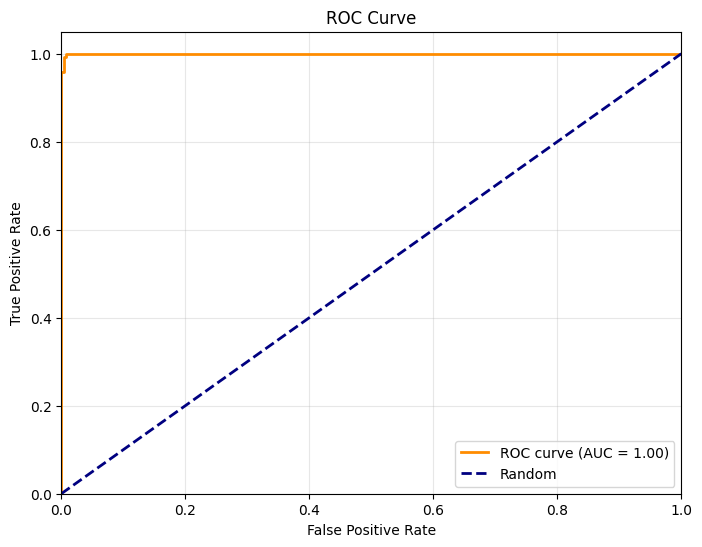

✓ ROC AUC Score: 0.9998


In [7]:
if siamese_model is not None:
    print("\nCreating ROC Curve...\n")

    fig, roc_auc = utils.plot_roc_curve(y_true, y_pred)
    plt.show()

    print(f"✓ ROC AUC Score: {roc_auc:.4f}")

## 5.8 Prediction Distribution

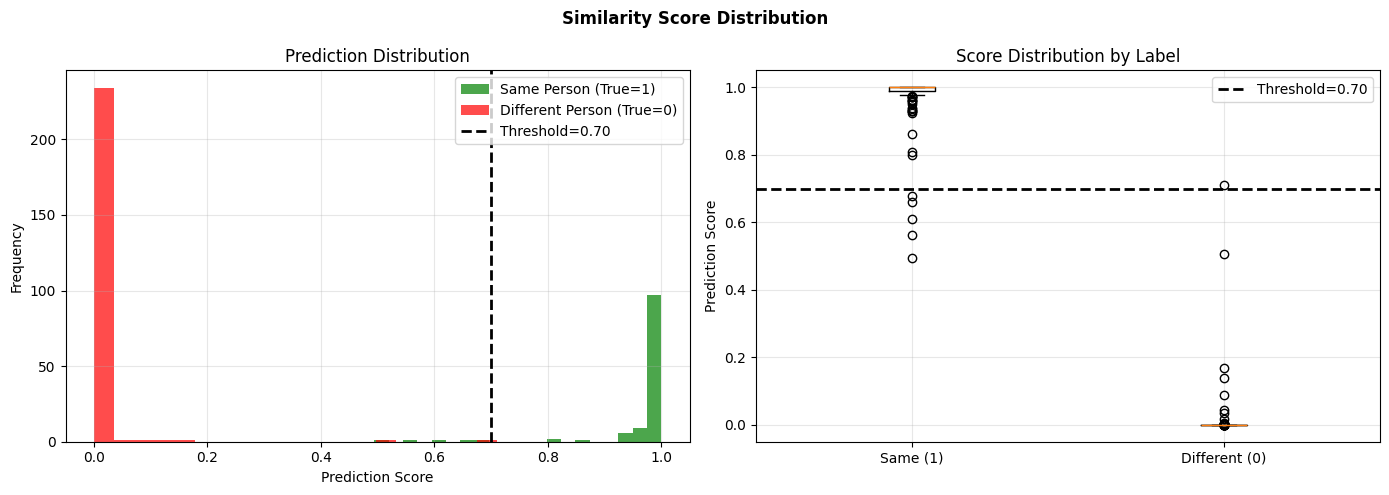

 Reload if not properly displayed


In [8]:
if siamese_model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(y_pred[y_true == 1], bins=20, alpha=0.7, label='Same Person (True=1)', color='green')
    axes[0].hist(y_pred[y_true == 0], bins=20, alpha=0.7, label='Different Person (True=0)', color='red')
    axes[0].axvline(x=config.VERIFICATION_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold={config.VERIFICATION_THRESHOLD:.2f}')
    axes[0].set_xlabel('Prediction Score')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Prediction Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    data_to_plot = [y_pred[y_true == 1], y_pred[y_true == 0]]
    axes[1].boxplot(data_to_plot)
    axes[1].set_xticklabels(['Same (1)', 'Different (0)'])
    axes[1].axhline(y=config.VERIFICATION_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold={config.VERIFICATION_THRESHOLD:.2f}')
    axes[1].set_ylabel('Prediction Score')
    axes[1].set_title('Score Distribution by Label')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle('Similarity Score Distribution', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(" Reload if not properly displayed")

## 5.9 Summary & Recommendations

In [9]:
print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)

if siamese_model is not None:
    print(f"\n✓ Test Data Evaluation:")
    print(f"  Total Samples: {len(y_pred)}")
    print(f"  Same Person: {int(np.sum(y_true))}")
    print(f"  Different Person: {len(y_pred) - int(np.sum(y_true))}")

    print(f"\n✓ Performance (Threshold={config.VERIFICATION_THRESHOLD:.4f}):")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1']:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")

    print(f"\n✓ Recommendation:")
    if best_threshold != config.VERIFICATION_THRESHOLD:
        print(f"  → Config Threshold: {config.VERIFICATION_THRESHOLD:.4f}")
        print(f"  → Optimal Threshold: {best_threshold:.4f}")
        print(f"     (F1-Score Improvement: {best_metrics['f1'] - metrics['f1']:+.4f})")
    else:
        print(f"  → Threshold {config.VERIFICATION_THRESHOLD:.4f} is optimal")

    print(f"\nNext Step:")
    print(f"  → Notebook 06_inference.ipynb: Live Verification with Webcam")
else:
    print(" Evaluation not completed")

print("\n" + "="*80)
print("✓ Notebook 05 completed!")
print("="*80)


EVALUATION SUMMARY

✓ Test Data Evaluation:
  Total Samples: 360
  Same Person: 120
  Different Person: 240

✓ Performance (Threshold=0.7000):
  Accuracy: 0.9833
  F1-Score: 0.9746
  ROC AUC: 0.9998

✓ Recommendation:
  → Config Threshold: 0.7000
  → Optimal Threshold: 0.9500
     (F1-Score Improvement: -0.0365)

Next Step:
  → Notebook 06_inference.ipynb: Live Verification with Webcam

✓ Notebook 05 completed!
